# Introduction

In [2]:
!pip install -q pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 57.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 57.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 100.8 MB/s eta 0:00:0000:0100:01


In [3]:
import pennylane as qp
import numpy as np 


In [5]:
# create a quantum device for execution
dev = qp.device("default.qubit")
print(dev)

<default.qubit device at 0x7bac50fb11c0>


A quantum node is used to declare the quantum circuit like the below figure

(<Figure size 700x300 with 1 Axes>, <Axes: >)

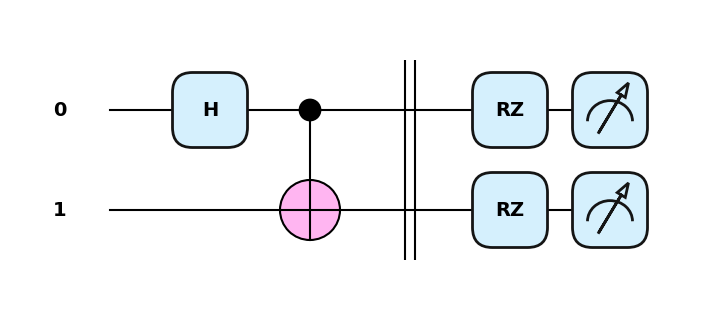

In [17]:
# create a quantum program
@qp.qnode(dev)
def program(angles):
    qp.H(       wires=0)
    qp.CNOT(    wires=[0,1])

    qp.Barrier()

    qp.RZ(angles[0], wires=0)
    qp.RZ(angles[1], wires=1)

    return qp.state()

qp.drawer.use_style('pennylane')
qp.draw_mpl(program)(np.array([1,2]))

# Quantum circuits

- QNodes use the NumPy interface by default and support other like PyTorch, and JAX.

- QNode is the smallest component in the quantum circuits.

- Quantum circuits like a Python function

In [22]:
import pennylane as qp

"""
A quantum gate with parameters x and y.
RZ and RY are rotate gate, which mean rotate X and Y.
CNOT is Controlled-NOT this gate create quantum engtanglement
And What is Quantum Engtanglement?

x, y can be classical input or 
quantum operators or sequence of operators called Templates

The quantum function always return either a single or
a tuple of measurement values.
"""
@qp.qnode(dev)
def my_quantum_function(x, y):
    qp.RZ(x, wires=0)
    qp.CNOT(wires=[0,1])
    qp.RY(y, wires=1)

    return qp.expval(qp.Z(wires=1))
my_quantum_function(2, 3)

np.float64(-0.9899924966004455)

*Wires*
- In PennyLane, wires is a quantum subsystem, corresponding to a qubit. And in continuous-variable devices, a wire corrponds to a quantum mode (quantum device real or simulated).

The simple syntax is stop here because you can learn it by reading online document from the official pennylane or by AI. So now I will focus in machine learning